In [1]:
import math
import random
import mappings as maps
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy import signal
from sbox import Sbox
import ciphers

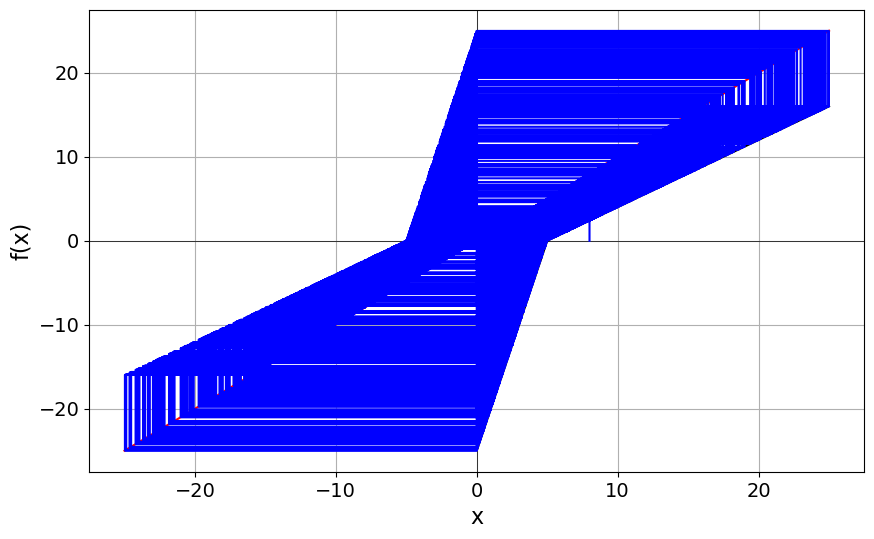

In [2]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot()
ax.grid(True, which='both')
ax.axhline(y=0, color='k',lw=0.5)
ax.axvline(x=0, color='k',lw=0.5)

xini = 8
xini2 = xini+0.0001
x,y,px,py = maps.mapping_pwlmOrbit(xini,dyn_sysparams=[0.8,5,4],orbit_size=3000)
x2,y2,px2,py2 = maps.mapping_pwlmOrbit(xini2,dyn_sysparams=[0.7,8,2.1875],orbit_size=5000)

maplenXY=int(len(x)/2)
maplenXY2=int(len(x2)/2)
ax.plot(x[maplenXY:],y[maplenXY:],'k')
# ax.plot(x[:maplenXY],y[:maplenXY],'k')
# ax.plot(x2[maplenXY:],y2[maplenXY:],'k')
# ax.plot(x2[:maplenXY],y2[:maplenXY],'k')
# ax.plot(x,y,'k')
ax.plot(x,x,'r')
# ax.plot(px[0:200],py[0:200],'b')
ax.plot(px,py,'b')
# ax.plot(px2,py2)
ax.set_ylabel('f(x)',fontsize=16)
ax.set_xlabel('x',fontsize=16)

# ax.set_xlim(-4,4)
# ax.set_ylim(np.min(y),np.max(y))
ax.tick_params(axis='both',labelsize=14)

plt.show()

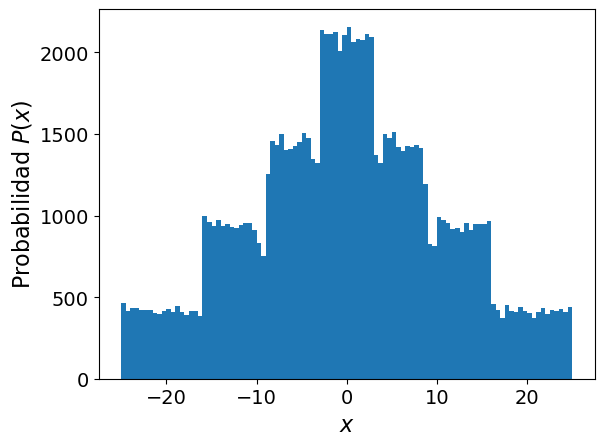

In [31]:
x_0 = 0.2
nmax = 100000
f_params = [0.8,5,4]
orbit = np.empty(nmax)
orbit[0] = x_0
for i in range(1,nmax):
    orbit[i] = maps.pwlm(orbit[i-1],f_params[0],f_params[1],f_params[2])




plt.hist(orbit,bins=100)


plt.xlabel('$x$',fontsize=16)
# plt.ylim(0,0.25)}]
plt.ylabel("Probabilidad $P(x)$",fontsize=16)
plt.tick_params(axis='both',labelsize=14)

#plt.ylim(min(count[1]),max(count[1]))
plt.show()

# Might $g(x_n)=f_{PWL}(x_n)*1.001-\lfloor  f_{PWL}(x_n)*1.001 \rfloor$
# be chaotic? no fixed points? similar characteristics as f_{pwl}

## Cobweb diagram

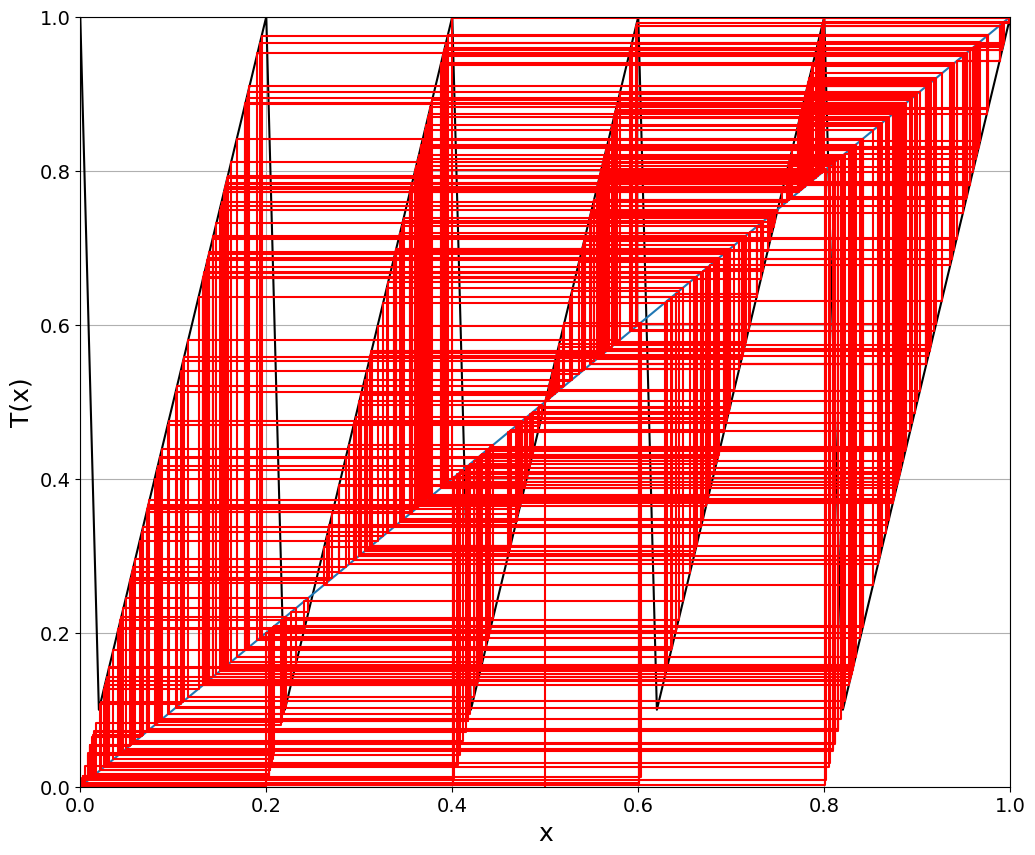

In [9]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot()

x0 = 0.5
nmax =1000
f2 = [0.8,5,40.8]
px, py = np.empty((2,nmax+1))
px[0], py[0] = x0, 0
x = np.arange(-5,5,0.02)
y = []
for i in range(len(x)):
    y.append(maps.frac_part(maps.pwlm(x[i],f2[0],f2[1],f2[2])))
# Cobweb diagram

for n in range(1, nmax, 2):
    px[n] = px[n-1]
    py[n] = maps.frac_part(maps.pwlm(px[n-1],f2[0],f2[1],f2[2]))
    px[n+1] = py[n]
    py[n+1] = py[n]

ax.plot(x,y,'k')
ax.plot(x,x)
ax.plot(px,py,'r')

#plt.title("Diagrama de Cobweb de la función PWL",fontsize=18)
plt.xlabel('x',fontsize=18)
plt.ylabel("T(x)",fontsize=18)
plt.tick_params(labelsize=14)
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid()

plt.show()

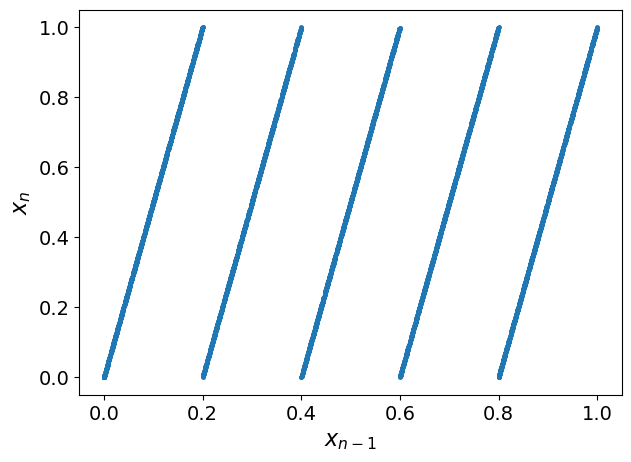

In [11]:
#PLOT X_N-1,X_N
from random import randrange
x_0 = randrange(1) 
f2 = [0.8,5,40.8]
orbit1 = []
orbit2=[]
# x1 = y_0
x2 = x_0
for i in range(6000):
    orbit2.append(x2)
    x2 = maps.frac_part(maps.pwlm(x2,f2[0],f2[1],f2[2]))
    

# xn_minus1 = orbit1[:-1]
# xn = orbit1[1:]
xn_minus12 = orbit2[:-1]
xn2 = orbit2[1:]
plt.figure(figsize=(7,5))
#plt.plot(xn_minus1, xn, '.', markersize=5, label="Orbit points")
plt.plot(xn_minus12, xn2, '.', markersize=5, label="Orbit points")
plt.xlabel('$x_{n-1}$',fontsize=16)
# plt.xlim(min(orbit2),max(orbit2))
plt.ylabel("$x_n$",fontsize=16)
# plt.ylim(min(orbit2),max(orbit2))
plt.tick_params(axis='both',labelsize=14)
# plt.xlim(-256,256)
# plt.ylim(-256,256)
# plt.grid()

plt.show()

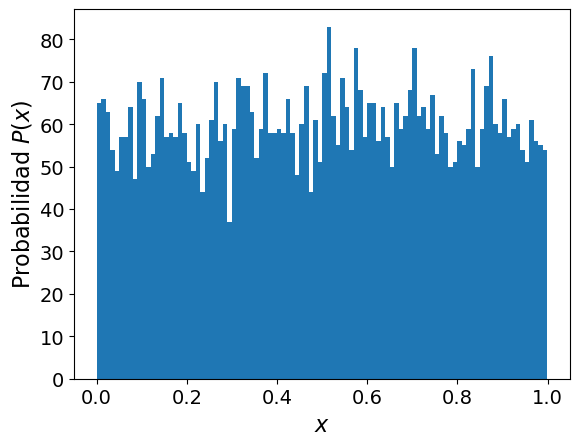

In [24]:
# discreteorbit1 = np.abs(np.floor(orbit2))

# unique =np.unique(discreteorbit1)
# hist,bins=np.histogram(orbit2, bins=50)
# count=np.asarray((bins,hist))
# plt.figure(figsize=(7,5))
plt.hist(orbit2,bins=100)
plt.xlabel('$x$',fontsize=16)
# plt.ylim(0,0.25)}]
plt.ylabel("Probabilidad $P(x)$",fontsize=16)
plt.tick_params(axis='both',labelsize=14)

#plt.ylim(min(count[1]),max(count[1]))
plt.show()

In [ ]:
def get_bits(byte, start, length):
    mask = (1 << length) - 1
    result = (byte >> int(np.mod((start - length + 1),8))) & mask
    return result

def ror(n,rotations,width):
    return (2**width-1)&(n>>rotations|n<<(width-rotations))

mask = (1 << 6) - 1
print(f"i=-1, res={mask:08b}")
for i in range(10):
    res = ror(mask,np.mod(i+1,8),8)
    print(f"i={i}, res={res:08b}")
    # byte = i  # Scale to 0-255 and convert to integer
    # c = np.mod(i,8)
    # bits = get_bits(byte,i, 6)  # Get the 6 bits
    # print(f"Value: {i:.6f}, Byte: {bin(byte)}, 6 MSBs: {bits:06b}")  # Print in binary format

i=-1, res=00111111
i=0, res=10011111
i=1, res=11001111
i=2, res=11100111
i=3, res=11110011
i=4, res=11111001
i=5, res=11111100
i=6, res=01111110
i=7, res=00111111
i=8, res=10011111
i=9, res=11001111


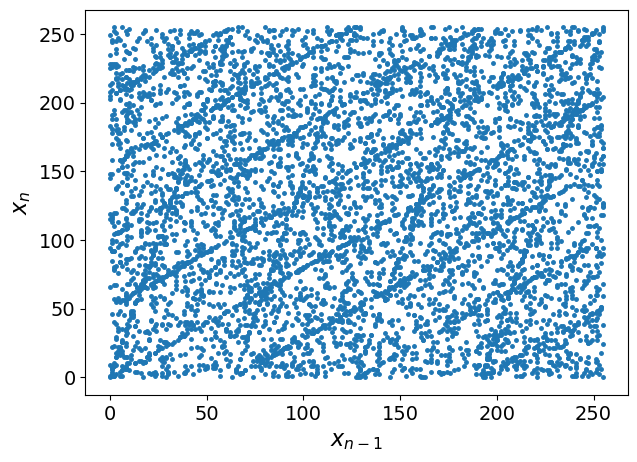

In [90]:
def prng_test(x01,delay=10,f1=[0.8,4,31],sblen=256):
    x1 = [x01]
    m1_seq = 0
    m2_seq = 0
    delayhf = int(delay*0.5)
    sb = []

    i = 0
    while len(sb) < sblen:
        x1.append(maps.pwlm(x1[i],f1[0],f1[1],f1[2])) #x1(n+1)=f(x1(n))
        if i>= delay:
            m1_seq = maps.frac_part((x1[int(i-(delay))]+x1[int(i-(delayhf))]+x1[int(i)]))
            sb.append(int(np.floor(m1_seq*256)))

        i+=1
    
    SBseq = np.array(sb)
    return SBseq.astype(np.uint8)



x0=2.0
orbit2=prng_test(x0,delay=10,sblen=6000)
    

# xn_minus1 = orbit1[:-1]
# xn = orbit1[1:]
xn_minus12 = orbit2[:-1]
xn2 = orbit2[1:]
plt.figure(figsize=(7,5))
#plt.plot(xn_minus1, xn, '.', markersize=5, label="Orbit points")
plt.plot(xn_minus12, xn2, '.', markersize=5, label="Orbit points")
plt.xlabel('$x_{n-1}$',fontsize=16)
# plt.xlim(min(orbit2),max(orbit2))
plt.ylabel("$x_n$",fontsize=16)
# plt.ylim(min(orbit2),max(orbit2))
plt.tick_params(axis='both',labelsize=14)
# plt.xlim(-256,256)
# plt.ylim(-256,256)
# plt.grid()

plt.show()

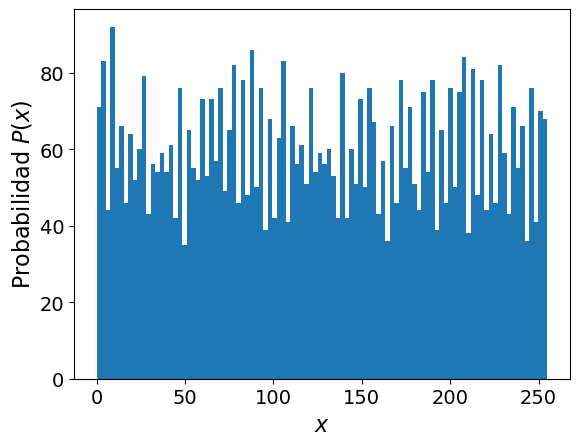

In [91]:
plt.hist(orbit2,bins=100)
plt.xlabel('$x$',fontsize=16)
# plt.ylim(0,0.25)}]
plt.ylabel("Probabilidad $P(x)$",fontsize=16)
plt.tick_params(axis='both',labelsize=14)

#plt.ylim(min(count[1]),max(count[1]))
plt.show()

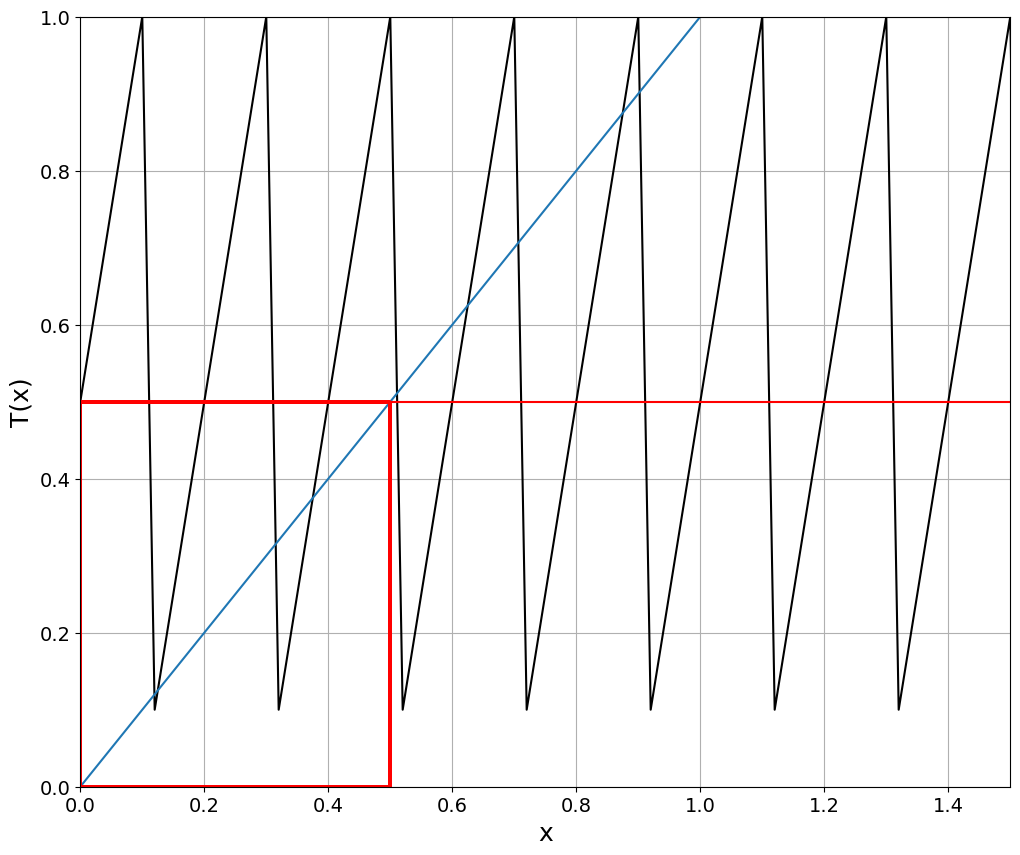

In [100]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot()

x0 = 2
nmax =1000
f2 = [0.8,5,6]
px, py = np.empty((2,nmax+1))
px[0], py[0] = x0, 0
x = np.arange(-5,5,0.02)
y = []
for i in range(len(x)):
    y.append(maps.frac_part(maps.pwlm(x[i],f2[0],f2[1],f2[2])))
# Cobweb diagram

for n in range(1, nmax, 2):
    px[n] = px[n-1]
    py[n] = maps.frac_part(maps.pwlm(px[n-1],f2[0],f2[1],f2[2]))
    px[n+1] = py[n]
    py[n+1] = py[n]

ax.plot(x,y,'k')
ax.plot(x,x)
ax.plot(px,py,'r')

#plt.title("Diagrama de Cobweb de la función PWL",fontsize=18)
plt.xlabel('x',fontsize=18)
plt.ylabel("T(x)",fontsize=18)
plt.tick_params(labelsize=14)
plt.xlim(0,1.5)
plt.ylim(0,1)
plt.grid()

plt.show()

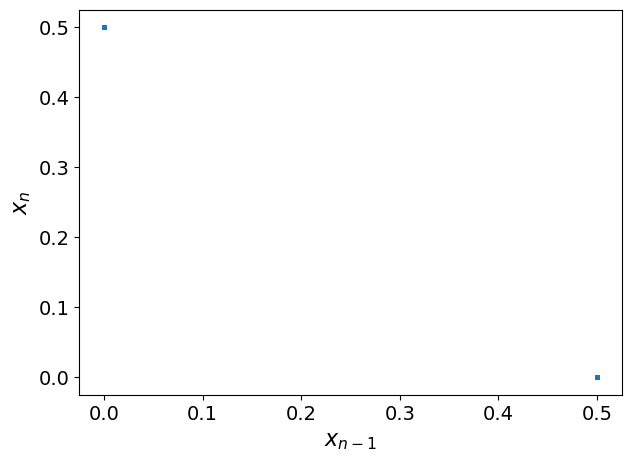

In [95]:
#PLOT X_N-1,X_N
from random import randrange
x_0 = randrange(1) 
f2 = [0.8,5,6]
orbit1 = []
orbit2=[]
# x1 = y_0
x2 = x_0
for i in range(6000):
    orbit2.append(x2)
    x2 = maps.frac_part(maps.pwlm(x2,f2[0],f2[1],f2[2]))
    

# xn_minus1 = orbit1[:-1]
# xn = orbit1[1:]
xn_minus12 = orbit2[:-1]
xn2 = orbit2[1:]
plt.figure(figsize=(7,5))
#plt.plot(xn_minus1, xn, '.', markersize=5, label="Orbit points")
plt.plot(xn_minus12, xn2, '.', markersize=5, label="Orbit points")
plt.xlabel('$x_{n-1}$',fontsize=16)
# plt.xlim(min(orbit2),max(orbit2))
plt.ylabel("$x_n$",fontsize=16)
# plt.ylim(min(orbit2),max(orbit2))
plt.tick_params(axis='both',labelsize=14)
# plt.xlim(-256,256)
# plt.ylim(-256,256)
# plt.grid()

plt.show()

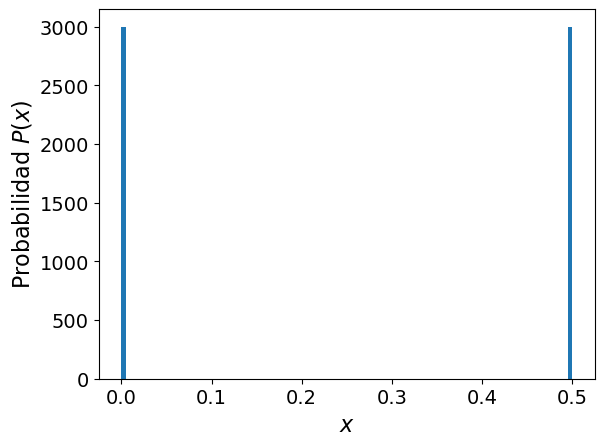

In [101]:
plt.hist(orbit2,bins=100)
plt.xlabel('$x$',fontsize=16)
# plt.ylim(0,0.25)}]
plt.ylabel("Probabilidad $P(x)$",fontsize=16)
plt.tick_params(axis='both',labelsize=14)

#plt.ylim(min(count[1]),max(count[1]))
plt.show()

In [2]:
#
# Copyright (C) 2019 Luca Pasqualini
# University of Siena - Artificial Intelligence Laboratory - SAILab
#
# Inspired by the work of David Johnston (C) 2017: https://github.com/dj-on-github/sp800_22_tests
#
# NistRng is licensed under a BSD 3-Clause.
#
# You should have received a copy of the license along with this
# work. If not, see <https://opensource.org/licenses/BSD-3-Clause>.

# Import packages

import numpy

# Import src

from nistrng import *

if __name__ == "__main__":
    # Generate the sequence of integers and pack it in its 8-bit representation
    sequence: numpy.ndarray = ciphers.prng_sbox(0.123456789,0.987654321,delay=10,f1=[0.8,5,40.8],f2=[0.9,4,31],sblen=10000)
    binary_sequence: numpy.ndarray = pack_sequence(sequence)
    # Print sequence
    print("Random sequence generated by NumPy:")
    print(sequence)
    print("Random sequence generated by NumPy encoded in 8-bit signed format:")
    print(binary_sequence)
    print("Original sequence taken back by unpacking (to check the correctness of packing process:")
    print(unpack_sequence(binary_sequence))
    # Check the eligibility of the test and generate an eligible battery from the default NIST-sp800-22r1a battery
    eligible_battery: dict = check_eligibility_all_battery(binary_sequence, SP800_22R1A_BATTERY)
    # Print the eligible tests
    print("Eligible test from NIST-SP800-22r1a:")
    for name in eligible_battery.keys():
        print("-" + name)
    # Test the sequence on the eligible tests
    results = run_all_battery(binary_sequence, eligible_battery, False)
    # Print results one by one
    print("Test results:")
    for result, elapsed_time in results:
        if result.passed:
            print("- PASSED - score: " + str(numpy.round(result.score, 3)) + " - " + result.name + " - elapsed time: " + str(elapsed_time) + " ms")
        else:
            print("- FAILED - score: " + str(numpy.round(result.score, 3)) + " - " + result.name + " - elapsed time: " + str(elapsed_time) + " ms")

Random sequence generated by NumPy:
[222 117  28 ... 136  25 103]
Random sequence generated by NumPy encoded in 8-bit signed format:
[1 1 0 ... 1 1 1]
Original sequence taken back by unpacking (to check the correctness of packing process:
[ -34  117   28 ... -120   25  103]
Eligible test from NIST-SP800-22r1a:
-monobit
-frequency_within_block
-runs
-longest_run_ones_in_a_block
-binary_matrix_rank
-dft
-non_overlapping_template_matching
-serial
-approximate_entropy
-cumulative sums
-random_excursion
-random_excursion_variant
Test results:
- PASSED - score: 0.656 - Monobit - elapsed time: 0 ms
- PASSED - score: 0.474 - Frequency Within Block - elapsed time: 1 ms
- PASSED - score: 0.849 - Runs - elapsed time: 16 ms
- PASSED - score: 0.959 - Longest Run Ones In A Block - elapsed time: 13 ms
- PASSED - score: 0.371 - Binary Matrix Rank - elapsed time: 331 ms
- FAILED - score: 0.0 - Discrete Fourier Transform - elapsed time: 3 ms
- PASSED - score: 0.279 - Non Overlapping Template Matching - 

In [7]:
def frac_prng(x01,x02,delay=10,f1=[0.8,5,40.8],f2=[0.9,4,31],sblen=10000):
    x1 = [x01]
    x2 = [x02]
    m1_seq = 0
    m2_seq = 0
    delayhf = int(delay*0.5)
    sb = []

    i = 0
    while len(sb) < sblen:
        x1.append(maps.pwlm(x1[i],f1[0],f1[1],f1[2])) #x1(n+1)=f(x1(n))
        x2.append(maps.pwlm(x2[i],f2[0],f2[1],f2[2]))

        if i>= delay:
            m1_seq = (x1[int(i-(delay))]+x1[int(i-(delayhf))]+x1[int(i)])%256
            m2_seq = (x2[int(i-(delay))]+x2[int(i-(delayhf+1))]+x2[int(i)])%256
            Zi = maps.frac_part((m1_seq + m2_seq))%256
            Zi = math.floor((Zi)*256)
            sb.append(Zi)

        i+=1

    return np.array(sb).astype(numpy.int8)

if __name__ == "__main__":
    # Generate the sequence of integers and pack it in its 8-bit representation
    sequence: numpy.ndarray = frac_prng(0.123456789,0.987654321,delay=10,f1=[0.8,5,4],f2=[0.8,5,4],sblen=10000)
    binary_sequence: numpy.ndarray = pack_sequence(sequence)
    # Print sequence
    print("Random sequence generated by NumPy:")
    print(sequence)
    print("Random sequence generated by NumPy encoded in 8-bit signed format:")
    print(binary_sequence)
    print("Original sequence taken back by unpacking (to check the correctness of packing process:")
    print(unpack_sequence(binary_sequence))
    # Check the eligibility of the test and generate an eligible battery from the default NIST-sp800-22r1a battery
    eligible_battery: dict = check_eligibility_all_battery(binary_sequence, SP800_22R1A_BATTERY)
    # Print the eligible tests
    print("Eligible test from NIST-SP800-22r1a:")
    for name in eligible_battery.keys():
        print("-" + name)
    # Test the sequence on the eligible tests
    results = run_all_battery(binary_sequence, eligible_battery, False)
    # Print results one by one
    print("Test results:")
    for result, elapsed_time in results:
        if result.passed:
            print("- PASSED - score: " + str(numpy.round(result.score, 3)) + " - " + result.name + " - elapsed time: " + str(elapsed_time) + " ms")
        else:
            print("- FAILED - score: " + str(numpy.round(result.score, 3)) + " - " + result.name + " - elapsed time: " + str(elapsed_time) + " ms")

Random sequence generated by NumPy:
[ 94   3   8 ... -64  98   6]
Random sequence generated by NumPy encoded in 8-bit signed format:
[0 1 0 ... 1 1 0]
Original sequence taken back by unpacking (to check the correctness of packing process:
[ 94   3   8 ... -64  98   6]
Eligible test from NIST-SP800-22r1a:
-monobit
-frequency_within_block
-runs
-longest_run_ones_in_a_block
-binary_matrix_rank
-dft
-non_overlapping_template_matching
-serial
-approximate_entropy
-cumulative sums
-random_excursion
-random_excursion_variant
Test results:
- PASSED - score: 0.078 - Monobit - elapsed time: 1 ms
- PASSED - score: 0.268 - Frequency Within Block - elapsed time: 0 ms
- PASSED - score: 0.518 - Runs - elapsed time: 43 ms
- PASSED - score: 0.592 - Longest Run Ones In A Block - elapsed time: 37 ms
- PASSED - score: 0.303 - Binary Matrix Rank - elapsed time: 496 ms
- FAILED - score: 0.0 - Discrete Fourier Transform - elapsed time: 2 ms
- PASSED - score: 0.346 - Non Overlapping Template Matching - elapse